# California Residential Home Price Prediction
# Geographic Clustering with K Means

This notebook explores whether K means clustering on property coordinates adds useful geographic signal beyond County, City, and School District, by grouping properties into location based clusters.

In [31]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Section 1 - Setup and Data Loading

In [32]:
df_model = pd.read_csv('data/cleaned_data_with_district.csv')
print('Shape:', df_model.shape)

Shape: (397461, 23)


## Section 2 - Determining Cluster Count

Two checks are used to determine a reasonable number of clusters. First, the elbow method examines how much within cluster variance is reduced as cluster count increases. Second, since the ultimate goal is a useful pricing feature, average ClosePrice separation across clusters is checked directly for each candidate k value.

In [33]:
coords = df_model[['Latitude', 'Longitude']]

inertias = []
k_range = range(2, 21)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords)
    inertias.append(km.inertia_)

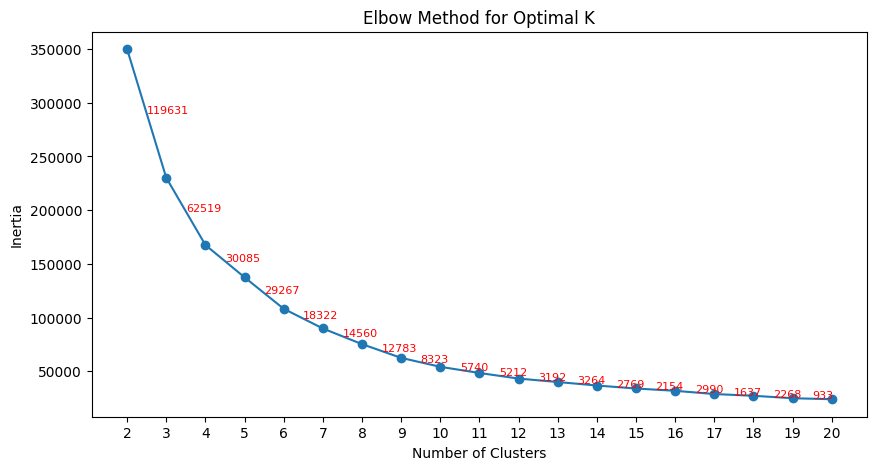

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)

for i in range(len(inertias) - 1):
    slope = inertias[i] - inertias[i+1]
    mid_x = (list(k_range)[i] + list(k_range)[i+1]) / 2
    mid_y = (inertias[i] + inertias[i+1]) / 2
    plt.annotate(f'{slope:.0f}', (mid_x, mid_y), fontsize=8, color='red')

plt.show()

In [35]:
results = []

for k in range(2, 21):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords)
    price_range = df_model.groupby(labels)['ClosePrice'].mean().max() - df_model.groupby(labels)['ClosePrice'].mean().min()
    results.append({'k': k, 'price_range': price_range})

results_df = pd.DataFrame(results)
print(results_df)

     k   price_range
0    2  2.092285e+05
1    3  3.489904e+05
2    4  6.735261e+05
3    5  6.456716e+05
4    6  1.024317e+06
5    7  1.024322e+06
6    8  1.037113e+06
7    9  1.037167e+06
8   10  1.302274e+06
9   11  1.303250e+06
10  12  1.300125e+06
11  13  1.298646e+06
12  14  1.361231e+06
13  15  1.361518e+06
14  16  1.357058e+06
15  17  1.340722e+06
16  18  1.340535e+06
17  19  1.346265e+06
18  20  1.615760e+06


## Section 3 - Applying K Means Clustering

Testing cluster counts from 2 through 20 shows a meaningful jump in average price separation between clusters at k equals 10, after which additional clusters through 19 provide little further separation. K equals 10 is selected as it captures this jump without adding unnecessary granularity.

In [36]:
kmeans_final = KMeans(n_clusters=10, random_state=42, n_init=10)
df_model['GeoCluster'] = kmeans_final.fit_predict(coords)

print(df_model['GeoCluster'].value_counts())

GeoCluster
9    91201
0    78190
2    61847
7    51936
5    43829
1    24903
8    19279
4     8984
3     8771
6     8521
Name: count, dtype: int64


## Section 4 - Summary

GeoCluster is added as a new categorical feature capturing location based pricing patterns beyond what County, City, and School District already provide. Testing across a range of cluster counts confirmed that k equals 10 captures the most meaningful jump in price separation before returns diminish.

In [37]:
df_model.to_csv('data/cleaned_data_final.csv', index=False)
print('Saved.')

Saved.
